[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evinracher/3010192-advanced-simulation/blob/feat/assigment-4/assignments/assignment4-game-simulation.ipynb)

# Simulación y Probabilidad Empírica en *Escaleras y Serpientes*

## Introducción

Este notebook estudia una versión de un solo jugador del juego de mesa colombiano *Escaleras y Serpientes* mediante simulación de Monte Carlo. El objetivo es explicar formalmente las reglas del juego, modelar su dinámica y analizar empíricamente el comportamiento de variables aleatorias relevantes a partir de un gran número de partidas simuladas.

### Reglas del juego

- El juego se desarrolla en un tablero con casillas numeradas del 1 al 100.
- El jugador inicia en la casilla 1.
- En cada turno se lanza un dado no cargado de seis caras.
- La ficha avanza según el resultado obtenido en el dado.
- Si el jugador cae exactamente en la base de una escalera, asciende inmediatamente a la casilla indicada.
- Si el jugador cae en la cabeza de una serpiente, desciende inmediatamente a la casilla correspondiente.
- El juego termina únicamente cuando el jugador cae exactamente en la casilla 100.
- Si un lanzamiento hace que la ficha sobrepase la casilla 100, el jugador permanece en la misma posición y el turno se cuenta.

### Descripción del tablero

- Casillas del tablero: `1` a `100`.
- Escaleras: `4→14`, `9→31`, `20→38`, `28→84`, `40→59`, `63→81`, `71→91`.
- Serpientes: `17→7`, `54→34`, `62→19`, `64→60`, `87→24`, `93→73`, `95→75`, `99→78`.

Estas casillas especiales introducen saltos hacia arriba y hacia abajo que modifican la duración y la trayectoria de cada partida.

### Supuestos de la simulación

- El dado no está cargado y cada resultado entre 1 y 6 tiene la misma probabilidad.
- Cada lanzamiento es independiente de los anteriores.
- Se modela un juego de un solo jugador.
- La configuración del tablero es fija durante toda la simulación.
- El jugador siempre comienza en la casilla 1.
- Las transiciones por escaleras y serpientes ocurren inmediatamente después de caer en la casilla correspondiente.
- Para ganar, se debe llegar exactamente a la casilla 100.

### Objetivo computacional

- Implementar una simulación reproducible del juego.
- Ejecutar un experimento de Monte Carlo con muchas partidas independientes.
- Estimar distribuciones empíricas y estadísticas descriptivas de las variables aleatorias definidas.

### Variables aleatorias analizadas

- `T`: número total de turnos requeridos para terminar el juego.
- `E`: número de veces que el jugador cae en una escalera durante una partida.
- `S`: número de veces que el jugador cae en una serpiente durante una partida.

Al simular muchas partidas independientes, es posible estimar la distribución empírica, el valor esperado, la variabilidad y probabilidades seleccionadas asociadas con estas variables aleatorias.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20260413
rng = np.random.default_rng(SEED)

BOARD_START = 1
BOARD_END = 100

LADDERS = {
    4: 14,
    9: 31,
    20: 38,
    28: 84,
    40: 59,
    63: 81,
    71: 91,
}

SNAKES = {
    17: 7,
    54: 34,
    62: 19,
    64: 60,
    87: 24,
    93: 73,
    95: 75,
    99: 78,
}

pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print(f'Semilla aleatoria fijada en {SEED}.')
print(f'Escaleras: {LADDERS}')
print(f'Serpientes: {SNAKES}')


Semilla aleatoria fijada en 20260413.
Escaleras: {4: 14, 9: 31, 20: 38, 28: 84, 40: 59, 63: 81, 71: 91}
Serpientes: {17: 7, 54: 34, 62: 19, 64: 60, 87: 24, 93: 73, 95: 75, 99: 78}


## Definición del Juego

La simulación sigue exactamente las reglas del juego:

- Juego de un solo jugador.
- El jugador inicia en la casilla 1.
- Cada turno consiste en lanzar un dado no cargado con resultados entre 1 y 6.
- Si el movimiento resultante supera la casilla 100, el jugador permanece en su lugar.
- Si el jugador cae en una escalera, la ficha sube inmediatamente.
- Si el jugador cae en una serpiente, la ficha baja inmediatamente.
- El juego termina solo cuando el jugador cae exactamente en la casilla 100.

El código está escrito de forma modular usando dos funciones principales:

- `simulate_one_game()` simula una partida completa y devuelve las variables aleatorias.
- `simulate_n_games(n)` repite el experimento muchas veces y almacena los resultados en un `pandas` DataFrame.


In [2]:
def simulate_one_game(rng_instance=None, return_path=False, verbose=False):
    """Simulate one complete game of Snakes and Ladders.

    Parameters
    ----------
    rng_instance : numpy random generator, optional
        Random number generator to use. If None, the global generator is used.
    return_path : bool, optional
        If True, returns a list with step-by-step information.
    verbose : bool, optional
        If True, prints the progress of the game.

    Returns
    -------
    tuple
        (T, E, S) or (T, E, S, path).
    """
    if rng_instance is None:
        rng_instance = rng

    position = BOARD_START
    turns = 0
    ladders_count = 0
    snakes_count = 0
    path = []

    while position != BOARD_END:
        turns += 1
        roll = int(rng_instance.integers(1, 7))
        proposed_position = position + roll
        event = 'movimiento normal'
        final_position = position

        if proposed_position > BOARD_END:
            event = 'supera 100, permanece en la misma casilla'
        else:
            final_position = proposed_position
            if final_position in LADDERS:
                ladders_count += 1
                final_position = LADDERS[final_position]
                event = 'escalera'
            elif final_position in SNAKES:
                snakes_count += 1
                final_position = SNAKES[final_position]
                event = 'serpiente'

        step_info = {
            'turn': turns,
            'start_position': position,
            'roll': roll,
            'proposed_position': proposed_position,
            'event': event,
            'final_position': final_position,
        }
        path.append(step_info)

        if verbose:
            print(
                f"Turno {turns:>2}: inicio={position:>3}, dado={roll}, "
                f"propuesta={proposed_position:>3}, evento={event}, final={final_position:>3}"
            )

        position = final_position

    if return_path:
        return turns, ladders_count, snakes_count, path
    return turns, ladders_count, snakes_count


def simulate_n_games(n, rng_instance=None):
    """Simulate n independent games and return the results in a DataFrame."""
    if rng_instance is None:
        rng_instance = rng

    records = [simulate_one_game(rng_instance=rng_instance) for _ in range(n)]
    return pd.DataFrame(records, columns=['T', 'E', 'S'])


## Simulación

Antes de ejecutar el experimento grande de Monte Carlo, es útil observar una partida completa paso a paso. Esta sección muestra cómo los lanzamientos del dado, la condición de caída exacta, las escaleras y las serpientes afectan la evolución del juego.


In [3]:
demo_rng = np.random.default_rng(SEED)
demo_T, demo_E, demo_S, demo_path = simulate_one_game(
    rng_instance=demo_rng,
    return_path=True,
    verbose=True,
)

print('\nResumen de la partida demostrativa:')
print(f'Turnos totales (T): {demo_T}')
print(f'Escaleras utilizadas (E): {demo_E}')
print(f'Serpientes encontradas (S): {demo_S}')

demo_df = pd.DataFrame(demo_path)
demo_df_display = demo_df.rename(columns={
    'turn': 'turno',
    'start_position': 'posicion_inicial',
    'roll': 'dado',
    'proposed_position': 'posicion_propuesta',
    'event': 'evento',
    'final_position': 'posicion_final',
})
demo_df_display.head(15)


Turno  1: inicio=  1, dado=2, propuesta=  3, evento=movimiento normal, final=  3
Turno  2: inicio=  3, dado=4, propuesta=  7, evento=movimiento normal, final=  7
Turno  3: inicio=  7, dado=4, propuesta= 11, evento=movimiento normal, final= 11
Turno  4: inicio= 11, dado=3, propuesta= 14, evento=movimiento normal, final= 14
Turno  5: inicio= 14, dado=5, propuesta= 19, evento=movimiento normal, final= 19
Turno  6: inicio= 19, dado=4, propuesta= 23, evento=movimiento normal, final= 23
Turno  7: inicio= 23, dado=2, propuesta= 25, evento=movimiento normal, final= 25
Turno  8: inicio= 25, dado=6, propuesta= 31, evento=movimiento normal, final= 31
Turno  9: inicio= 31, dado=4, propuesta= 35, evento=movimiento normal, final= 35
Turno 10: inicio= 35, dado=2, propuesta= 37, evento=movimiento normal, final= 37
Turno 11: inicio= 37, dado=1, propuesta= 38, evento=movimiento normal, final= 38
Turno 12: inicio= 38, dado=2, propuesta= 40, evento=escalera, final= 59
Turno 13: inicio= 59, dado=1, propues

,turno,posicion_inicial,dado,posicion_propuesta,evento,posicion_final
0,1,1,2,3,movimiento normal,3
1,2,3,4,7,movimiento normal,7
2,3,7,4,11,movimiento normal,11
3,4,11,3,14,movimiento normal,14
4,5,14,5,19,movimiento normal,19
5,6,19,4,23,movimiento normal,23
6,7,23,2,25,movimiento normal,25
7,8,25,6,31,movimiento normal,31
8,9,31,4,35,movimiento normal,35
9,10,35,2,37,movimiento normal,37


## Resultados

Ahora el notebook realiza una simulación de Monte Carlo con muchas partidas independientes. El conjunto de datos resultante almacena una observación por partida y una columna por variable aleatoria:

- `T`: número de turnos requeridos para terminar el juego.
- `E`: número de veces que se cae en una escalera.
- `S`: número de veces que se cae en una serpiente.

Usar un gran número de simulaciones permite que la distribución empírica aproxime la distribución de probabilidad subyacente del juego.


In [4]:
n_games = 10_000
simulation_rng = np.random.default_rng(SEED)
results_df = simulate_n_games(n_games, rng_instance=simulation_rng)

print(f'Número de partidas simuladas: {n_games}')
results_df.rename(columns={
    'T': 'T',
    'E': 'E',
    'S': 'S',
}).head()


Número de partidas simuladas: 10000


,T,E,S
0,78,5,8
1,15,3,1
2,97,6,11
3,52,4,4
4,19,3,0


## Análisis

Las siguientes celdas calculan estadísticas descriptivas y distribuciones de probabilidad empíricas para las tres variables aleatorias. Como el estudio se basa en simulación, las probabilidades se estiman como frecuencias relativas.


In [5]:
def empirical_distribution(series):
    counts = series.value_counts().sort_index()
    probabilities = series.value_counts(normalize=True).sort_index()
    return pd.DataFrame({
        'frequency': counts,
        'probability': probabilities,
    })


def descriptive_statistics(series):
    mode_values = series.mode().tolist()
    return pd.Series({
        'mean': series.mean(),
        'variance': series.var(ddof=0),
        'std_dev': series.std(ddof=0),
        'median': series.median(),
        'mode': ', '.join(str(value) for value in mode_values),
        'min': series.min(),
        'max': series.max(),
        'range': series.max() - series.min(),
    })


T_distribution = empirical_distribution(results_df['T'])
E_distribution = empirical_distribution(results_df['E'])
S_distribution = empirical_distribution(results_df['S'])

summary_table = pd.DataFrame({
    'T': descriptive_statistics(results_df['T']),
    'E': descriptive_statistics(results_df['E']),
    'S': descriptive_statistics(results_df['S']),
})

common_T = T_distribution.sort_values('probability', ascending=False).head(5)

probability_examples = pd.Series({
    'P(T <= 20)': (results_df['T'] <= 20).mean(),
    'P(T <= 30)': (results_df['T'] <= 30).mean(),
    'P(T <= 40)': (results_df['T'] <= 40).mean(),
    'P(E = 0)': (results_df['E'] == 0).mean(),
    'P(E >= 1)': (results_df['E'] >= 1).mean(),
    'P(S = 0)': (results_df['S'] == 0).mean(),
    'P(S >= 1)': (results_df['S'] >= 1).mean(),
})

summary_table_display = summary_table.rename(index={
    'mean': 'media',
    'variance': 'varianza',
    'std_dev': 'desviacion_estandar',
    'median': 'mediana',
    'mode': 'moda',
    'min': 'minimo',
    'max': 'maximo',
    'range': 'rango',
})

T_distribution_display = T_distribution.rename(columns={
    'frequency': 'frecuencia',
    'probability': 'probabilidad',
}).copy()
T_distribution_display['probabilidad'] = T_distribution_display['probabilidad'].map(lambda x: f'{x * 100:.2f}%')

E_distribution_display = E_distribution.rename(columns={
    'frequency': 'frecuencia',
    'probability': 'probabilidad',
}).copy()
E_distribution_display['probabilidad'] = E_distribution_display['probabilidad'].map(lambda x: f'{x * 100:.2f}%')

S_distribution_display = S_distribution.rename(columns={
    'frequency': 'frecuencia',
    'probability': 'probabilidad',
}).copy()
S_distribution_display['probabilidad'] = S_distribution_display['probabilidad'].map(lambda x: f'{x * 100:.2f}%')

common_T_display = common_T.rename(columns={
    'frequency': 'frecuencia',
    'probability': 'probabilidad',
}).copy()
common_T_display['probabilidad'] = common_T_display['probabilidad'].map(lambda x: f'{x * 100:.2f}%')

probability_examples_display = probability_examples.map(lambda x: f'{x * 100:.2f}%').to_frame(name='probabilidad')

print('Estadísticas descriptivas de T, E y S:')
display(summary_table_display)

print('Distribución empírica de T (primeros 15 valores):')
display(T_distribution_display.head(15))

print('Distribución empírica de E:')
display(E_distribution_display)

print('Distribución empírica de S:')
display(S_distribution_display)

print('Valores exactos más frecuentes de T y sus probabilidades estimadas:')
display(common_T_display)

print('Probabilidades empíricas seleccionadas:')
display(probability_examples_display)


Estadísticas descriptivas de T, E y S:


,T,E,S
media,63.02,3.50,6.64
varianza,2188.47,6.14,41.62
desviacion_estandar,46.78,2.48,6.45
mediana,49.00,3.00,5.00
moda,26,2,2
minimo,7,0,0
maximo,458,23,61
rango,451,23,61


Distribución empírica de T (primeros 15 valores):


,frecuencia,probabilidad
T,,
7,3,0.03%
8,11,0.11%
9,21,0.21%
10,33,0.33%
11,43,0.43%
12,57,0.57%
13,54,0.54%
14,78,0.78%
15,78,0.78%


Distribución empírica de E:


...

,frecuencia,probabilidad
S,,
0,785,7.85%
1,1040,10.40%
2,1094,10.94%
3,1003,10.03%
4,899,8.99%
...,...,...
50,1,0.01%
52,1,0.01%
53,1,0.01%


Valores exactos más frecuentes de T y sus probabilidades estimadas:


,frecuencia,probabilidad
T,,
26,173,1.73%
30,164,1.64%
24,163,1.63%
34,162,1.62%
33,160,1.60%


Probabilidades empíricas seleccionadas:


,probabilidad
P(T <= 20),9.42%
P(T <= 30),25.11%
P(T <= 40),39.83%
P(E = 0),1.93%
P(E >= 1),98.07%
P(S = 0),7.85%
P(S >= 1),92.15%


## Visualizaciones

Las siguientes figuras resumen la distribución de las variables aleatorias. El notebook usa únicamente `matplotlib`, una gráfica por figura y el estilo por defecto.


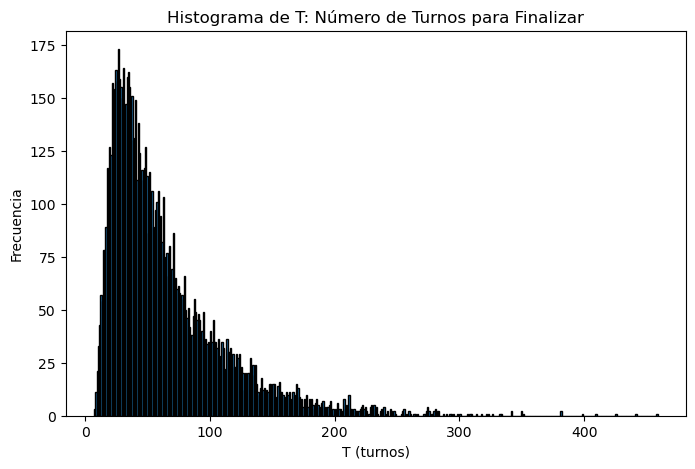

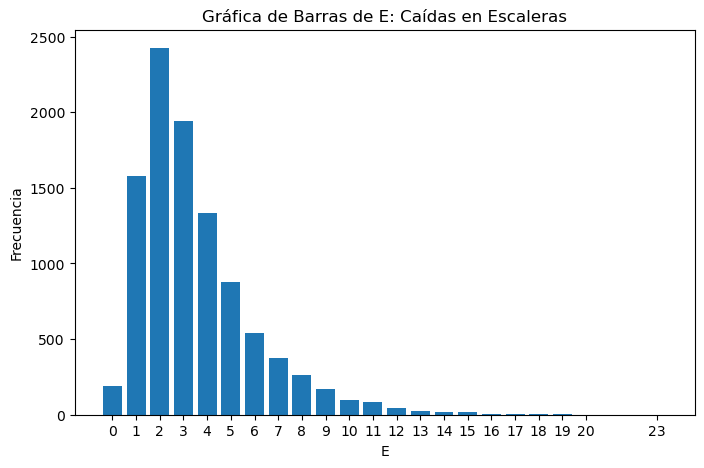

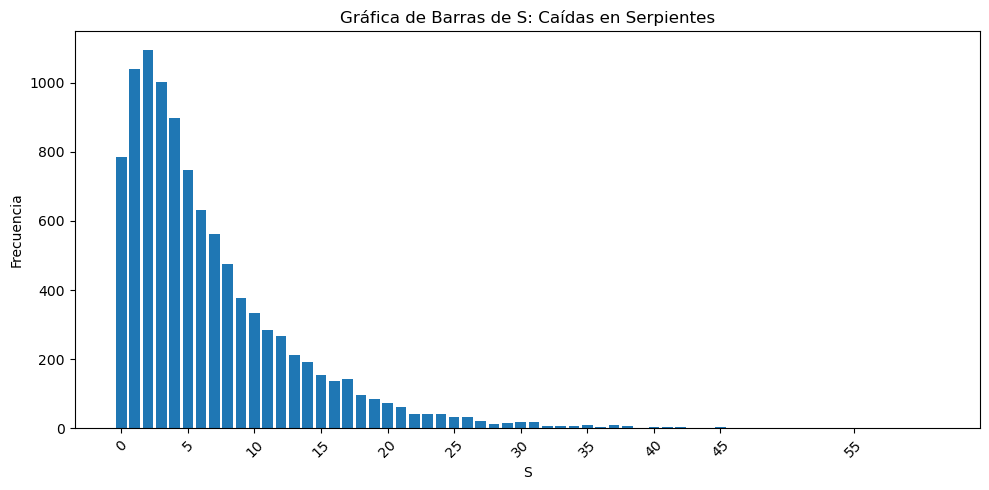

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(results_df['T'], bins=range(results_df['T'].min(), results_df['T'].max() + 2), edgecolor='black')
plt.title('Histograma de T: Número de Turnos para Finalizar')
plt.xlabel('T (turnos)')
plt.ylabel('Frecuencia')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(E_distribution.index, E_distribution['frequency'])
plt.title('Gráfica de Barras de E: Caídas en Escaleras')
plt.xlabel('E')
plt.ylabel('Frecuencia')
plt.xticks(E_distribution.index)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(S_distribution.index, S_distribution['frequency'])
plt.title('Gráfica de Barras de S: Caídas en Serpientes')
plt.xlabel('S')
plt.ylabel('Frecuencia')
snake_tick_step = max(1, int(np.ceil(len(S_distribution.index) / 12)))
plt.xticks(S_distribution.index[::snake_tick_step], rotation=45)
plt.tight_layout()
plt.show()


## Conclusiones

La simulación permite interpretar el juego desde una perspectiva probabilística:

- El valor promedio de `T` representa la duración típica del juego en turnos.
- La varianza y la desviación estándar de `T` cuantifican cuánto puede fluctuar la duración de una partida a otra.
- La variable `E` mide el efecto beneficioso de las escaleras, que reducen la distancia hasta la meta y pueden acortar considerablemente el juego.
- La variable `S` mide el efecto negativo de las serpientes, que hacen retroceder al jugador y aumentan la posibilidad de partidas largas.
- Comparar las distribuciones empíricas de `E` y `S` ayuda a explicar por qué algunas partidas terminan rápido mientras que otras requieren muchos más turnos.

En resumen, *Escaleras y Serpientes* es un ejemplo claro de un sistema estocástico en el que las transiciones aleatorias generan distribuciones observables para variables relevantes. La simulación de Monte Carlo proporciona una forma efectiva de estimar esas distribuciones y de conectar la probabilidad teórica con la experimentación computacional.


In [7]:
print('Resumen interpretativo basado en la simulación:')
print(f"Duración promedio del juego: {results_df['T'].mean():.2f} turnos.")
print(f"Desviación estándar de T: {results_df['T'].std(ddof=0):.2f} turnos.")
print(f"Número promedio de escaleras por partida: {results_df['E'].mean():.2f}.")
print(f"Número promedio de serpientes por partida: {results_df['S'].mean():.2f}.")
print(f"Probabilidad de usar al menos una escalera: {(results_df['E'] >= 1).mean() * 100:.2f}%.")
print(f"Probabilidad de caer en al menos una serpiente: {(results_df['S'] >= 1).mean() * 100:.2f}%.")


Resumen interpretativo basado en la simulación:
Duración promedio del juego: 63.02 turnos.
Desviación estándar de T: 46.78 turnos.
Número promedio de escaleras por partida: 3.50.
Número promedio de serpientes por partida: 6.64.
Probabilidad de usar al menos una escalera: 98.07%.
Probabilidad de caer en al menos una serpiente: 92.15%.
